### Сформулируем задачу

Допустим, требуется узнать пористость резервуарной единицы, для которой это измерение ещё не получено. Второй возможный сценарий - уточнение тектонического режима.

Нужно уточнить у заказчика:
- Что является новым объектом: ещё один пласт знакомого месторождения, новое месторождение или новый бассейн?
- В какой момент нужны сведения и какие измерения уже доступны к этому моменту?
- Как получены целевые значения: измерением, экспертной оценкой, справочником или усреднением?
- На каких объектах предполагается использовать результат: в тех же странах и литологиях или за пределами представленного состава?

### Подготовка окружения


In [ ]:
!pip install -q basemap phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 7.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import scipy
import phik
from matplotlib import pyplot as plt
from mpl_toolkits.basemap import Basemap
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

###  Посмотрим на данные

Набор данных состоит из 20 различных категориальных и непрерывных параметров 513 месторождений нефти.

In [ ]:
dataset_path = 'dataset_geologist.xlsx'

raw_data = pd.read_excel(dataset_path)
raw_data.head(5)

,Unnamed: 0,N,1. Field name,2. Reservoir unit,3. Country,4. Region,5. Basin name,6. Tectonic regime,7. Latitude,8. Longitude,...,11. Hydrocarbon type (main),12. Reservoir status (current),13. Structural setting,14. Depth (top reservoir ft TVD),15. Reservoir period,16. Lithology (main),17. Thickness (gross average ft),18. Thickness (net pay average ft),19. Porosity (matrix average %),20. Permeability (air average mD)
0,0,6,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION,26.0800,49.8100,...,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
1,1,10,ABU GHARADIG,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.7422,28.4925,...,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10282,CRETACEOUS,SANDSTONE,745.0,144.0,10.0,8.0
2,2,11,ABU MADI-EL QARA,ABU MADI (LEVEL II),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP,31.4382,31.3616,...,GAS,DECLINING PRODUCTION,WRENCH,9843,NEOGENE,THINLY-BEDDED SANDSTONE,115.0,66.0,22.0,200.0
3,3,12,ABU MADI-EL QARA,ABU MADI (LEVEL III),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP,31.4382,31.3616,...,GAS,DECLINING PRODUCTION,WRENCH,10499,NEOGENE,SANDSTONE,509.0,410.0,20.0,300.0
4,4,20,AL HUWAISAH,SHUAIBA,OMAN,MIDDLE EAST,FAHUD SALT,COMPRESSION,21.9607,56.0452,...,OIL,REJUVENATING,SALT,4955,CRETACEOUS,LIMESTONE,250.0,100.0,21.0,60.0


In [ ]:
raw_data.shape

(514, 22)

In [ ]:
column_names = {'Unnamed: 0': 'export_index', 'N': 'record_id', '1. Field name': 'field_name', '2. Reservoir unit': 'reservoir_unit', '3. Country': 'country', '4. Region': 'region', '5. Basin name': 'basin_name', '6. Tectonic regime': 'tectonic_regime', '7. Latitude': 'latitude', '8. Longitude': 'longitude', '9. Operator company': 'operator_company', '10. Onshore or offshore': 'location_type', '11. Hydrocarbon type (main)': 'hydrocarbon_type', '12. Reservoir status (current)': 'reservoir_status', '13. Structural setting': 'structural_setting', '14. Depth (top reservoir ft TVD)': 'depth_ft', '15. Reservoir period': 'reservoir_period', '16. Lithology (main)': 'lithology', '17. Thickness (gross average ft)': 'gross_thickness_ft', '18. Thickness (net pay average ft)': 'net_pay_thickness_ft', '19. Porosity (matrix average %)': 'porosity_pct', '20. Permeability (air average mD)': 'permeability_md'}
eda_data = raw_data.rename(columns=column_names).copy(deep=True)
measurement_columns = ['depth_ft', 'gross_thickness_ft', 'net_pay_thickness_ft', 'porosity_pct', 'permeability_md']
category_columns = ['country', 'region', 'basin_name', 'tectonic_regime', 'operator_company', 'location_type', 'hydrocarbon_type', 'reservoir_status', 'structural_setting', 'reservoir_period', 'lithology']
identifier_columns = ['export_index', 'record_id', 'field_name', 'reservoir_unit']
coordinate_columns = ['latitude', 'longitude']
field_key = ['country', 'field_name']
reservoir_key = ['country', 'field_name', 'reservoir_unit']
column_dictionary = pd.DataFrame({'source_column': list(column_names), 'eda_column': list(column_names.values())})
column_dictionary

,source_column,eda_column
0,Unnamed: 0,export_index
1,N,record_id
2,1. Field name,field_name
3,2. Reservoir unit,reservoir_unit
4,3. Country,country
5,4. Region,region
6,5. Basin name,basin_name
7,6. Tectonic regime,tectonic_regime
8,7. Latitude,latitude
9,8. Longitude,longitude


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          514 non-null    int64  
 1   N                                   514 non-null    int64  
 2   1. Field name                       514 non-null    object 
 3   2. Reservoir unit                   514 non-null    object 
 4   3. Country                          514 non-null    object 
 5   4. Region                           514 non-null    object 
 6   5. Basin name                       514 non-null    object 
 7   6. Tectonic regime                  442 non-null    object 
 8   7. Latitude                         514 non-null    float64
 9   8. Longitude                        514 non-null    float64
 10  9. Operator company                 514 non-null    object 
 11  10. Onshore or offshore             514 non-n

In [ ]:
raw_data.dtypes

,0
Unnamed: 0,int64
N,int64
1. Field name,object
2. Reservoir unit,object
3. Country,object
4. Region,object
5. Basin name,object
6. Tectonic regime,object
7. Latitude,float64
8. Longitude,float64


In [ ]:
raw_data.isna().sum()

,0
Unnamed: 0,0
N,0
1. Field name,0
2. Reservoir unit,0
3. Country,0
4. Region,0
5. Basin name,0
6. Tectonic regime,72
7. Latitude,0
8. Longitude,0


### Повторы месторождений

Сравним три определения дубля: вся запись, ключ резервуара и ключ месторождения.

In [ ]:
subject_columns = eda_data.columns.drop(['export_index', 'record_id']).tolist()
subject_duplicate_mask = eda_data.duplicated(subset=subject_columns, keep=False)
reservoir_duplicate_mask = eda_data.duplicated(subset=reservoir_key, keep=False)
field_sizes = eda_data.groupby(field_key, dropna=False).size().rename('reservoir_count')
identity_audit = pd.Series({
    'rows': len(eda_data),
    'record_id_unique': eda_data['record_id'].is_unique,
    'subject_duplicate_rows': int(subject_duplicate_mask.sum()),
    'reservoir_key_duplicate_rows': int(reservoir_duplicate_mask.sum()),
    'field_count': len(field_sizes),
    'fields_with_multiple_rows': int(field_sizes.gt(1).sum()),
    'maximum_rows_per_field': int(field_sizes.max()),
    'distinct_coordinate_pairs': len(eda_data[coordinate_columns].drop_duplicates())}, name='value')
identity_audit

,value
rows,514
record_id_unique,True
subject_duplicate_rows,0
reservoir_key_duplicate_rows,0
field_count,440
fields_with_multiple_rows,60
maximum_rows_per_field,5
distinct_coordinate_pairs,439


In [ ]:
example_field = eda_data['field_name'].eq('ABU MADI-EL QARA')
eda_data.loc[example_field, reservoir_key + ['depth_ft', 'lithology', 'porosity_pct']]

,country,field_name,reservoir_unit,depth_ft,lithology,porosity_pct
2,EGYPT,ABU MADI-EL QARA,ABU MADI (LEVEL II),9843,THINLY-BEDDED SANDSTONE,22.0
3,EGYPT,ABU MADI-EL QARA,ABU MADI (LEVEL III),10499,SANDSTONE,20.0


- 514 записей и 440 ключей месторождений.
- У 60 месторождений больше одной строки, максимум пять.
- Полных дублей и повторов выбранного ключа нет.
- Уникальных пар координат 439, а месторождений 440.

### Проверим качество данных

#### Одноколоночные проверки

- Конечность чисел и допустимые диапазоны координат (например, отрицательные толщина и проницаемость подозрительны по физическому смыслу)

In [ ]:
numeric_audit_columns = measurement_columns + coordinate_columns
finite_values = np.isfinite(eda_data[numeric_audit_columns].to_numpy(dtype=float))
non_missing_values = eda_data[numeric_audit_columns].notna().to_numpy()
non_finite_count = int((non_missing_values & ~finite_values).sum())
range_checks = pd.Series({
    'non_finite_non_missing_values': non_finite_count,
    'latitude_outside_minus90_plus90': int((eda_data['latitude'].notna() & ~eda_data['latitude'].between(-90, 90)).sum()),
    'longitude_outside_minus180_plus180': int((eda_data['longitude'].notna() & ~eda_data['longitude'].between(-180, 180)).sum()),
    'porosity_outside_0_100': int((eda_data['porosity_pct'].notna() & ~eda_data['porosity_pct'].between(0, 100)).sum()),
    'negative_depth': int(eda_data['depth_ft'].lt(0).sum()),
    'negative_gross_thickness': int(eda_data['gross_thickness_ft'].lt(0).sum()),
    'negative_net_pay_thickness': int(eda_data['net_pay_thickness_ft'].lt(0).sum()),
    'negative_permeability': int(eda_data['permeability_md'].lt(0).sum()),
    'zero_net_pay_thickness': int(eda_data['net_pay_thickness_ft'].eq(0).sum()),
    'nonpositive_permeability': int(eda_data['permeability_md'].le(0).sum())}, name='candidate_count')
range_checks

,candidate_count
non_finite_non_missing_values,0
latitude_outside_minus90_plus90,0
longitude_outside_minus180_plus180,0
porosity_outside_0_100,0
negative_depth,0
negative_gross_thickness,0
negative_net_pay_thickness,0
negative_permeability,0
zero_net_pay_thickness,1
nonpositive_permeability,0


- нет бесконечностей, выхода координат за допустимые диапазоны
- есть одна нулевая полезная толщина

#### Скрытые неизвестные значения и текстовые категории

`isna()` находит технические пропуски, но не знает предметного смысла строк `UNKNOWN`, `UNNAMED` и т.п. Проверим пробелы, пустые строки и варианты написания.

`UNKNOWN` обычно означает неизвестное значение, `UNNAMED` может означать отсутствие названия, а `NUMEROUS` - множество операторов.

In [ ]:
text_audit_rows = []
special_value_rows = []
for column in category_columns + ['field_name', 'reservoir_unit']:
    observed_text = eda_data[column].dropna().astype(str)
    normalized_text = observed_text.str.strip().str.upper()
    text_audit_rows.append({
        'column': column,
        'leading_or_trailing_space_count': int(observed_text.ne(observed_text.str.strip()).sum()),
        'blank_string_count': int(observed_text.str.strip().eq('').sum()),
        'raw_unique_count': observed_text.nunique(),
        'normalized_unique_count': normalized_text.nunique()
    })
    special_counts = observed_text.loc[normalized_text.isin(['UNKNOWN', 'UNNAMED', 'NUMEROUS'])].value_counts()
    for value in special_counts.index:
        special_value_rows.append({'column': column, 'value': value, 'count': int(special_counts.loc[value])})

text_audit = pd.DataFrame(text_audit_rows)
special_values = pd.DataFrame(special_value_rows)
text_audit

,column,leading_or_trailing_space_count,blank_string_count,raw_unique_count,normalized_unique_count
0,country,0,0,51,51
1,region,0,0,7,7
2,basin_name,0,0,121,121
3,tectonic_regime,0,0,9,9
4,operator_company,0,0,200,200
5,location_type,0,0,3,3
6,hydrocarbon_type,0,0,6,6
7,reservoir_status,0,0,14,14
8,structural_setting,0,0,12,12
9,reservoir_period,0,0,15,15


In [ ]:
special_values

,column,value,count
0,operator_company,NUMEROUS,45
1,operator_company,UNKNOWN,1
2,reservoir_status,UNKNOWN,14
3,reservoir_unit,UNNAMED,5
4,reservoir_unit,NUMEROUS,1


In [ ]:
eda_data['reservoir_status'].value_counts(dropna=False).rename('count').to_frame()

,count
reservoir_status,
DECLINING PRODUCTION,158
NEARLY DEPLETED,97
MATURE PRODUCTION,96
PLATEAU PRODUCTION,46
DEVELOPING,32
REJUVENATING,28
UNKNOWN,14
UNDEVELOPED,14
SECOND PLATEAU PRODUTION,9


- в статусе есть 14 `UNKNOWN`
- в операторе один `UNKNOWN` и 45 `NUMEROUS`
- в резервуарной единице пять  `UNNAMED`.
- есть также названия с `UNNAMED` внутри
- в статусах видно `SECOND PLATEAU PRODUTION` (опечатка)



#### Проверка согласованности толщин

Если общая и полезная толщины описывают сопоставимый интервал и согласованные определения, ожидаем `net pay <= gross`

In [ ]:
thickness_complete_mask = eda_data[['gross_thickness_ft', 'net_pay_thickness_ft']].notna().all(axis=1)
thickness_data = eda_data.loc[thickness_complete_mask, reservoir_key + ['gross_thickness_ft', 'net_pay_thickness_ft']].copy()
thickness_data['review_needed'] = thickness_data['net_pay_thickness_ft'].gt(thickness_data['gross_thickness_ft'])
positive_thickness_data = thickness_data.loc[thickness_data['gross_thickness_ft'].gt(0) & thickness_data['net_pay_thickness_ft'].gt(0)]

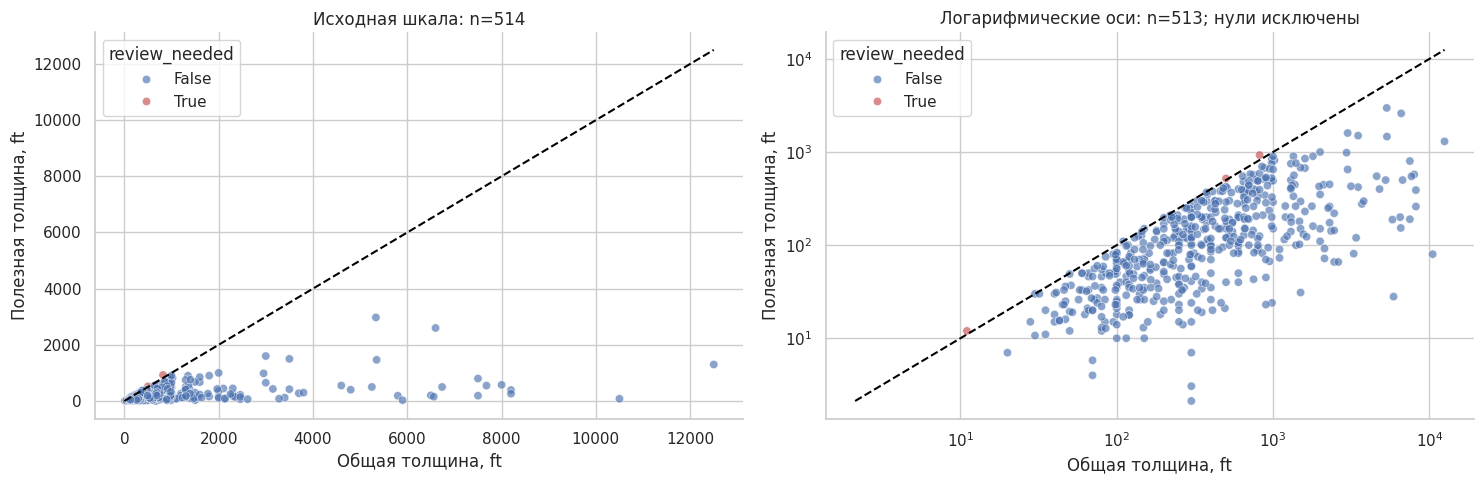

In [ ]:
subplot_result = plt.subplots(1, 2, figsize=(15, 5))
figure = subplot_result[0]
axes = subplot_result[1]
for axis in axes:
    plot_data = thickness_data if axis is axes[0] else positive_thickness_data
    sns.scatterplot(data=plot_data, x='gross_thickness_ft', y='net_pay_thickness_ft', hue='review_needed', palette={False: '#4C72B0', True: '#C44E52'}, alpha=0.65, ax=axis)
    axis.set_xlabel('Общая толщина, ft')
    axis.set_ylabel('Полезная толщина, ft')

linear_limit = float(thickness_data[['gross_thickness_ft', 'net_pay_thickness_ft']].max().max())
axes[0].plot([0, linear_limit], [0, linear_limit], color='black', linestyle='--', label='Равенство толщин')
axes[0].set_title(f'Исходная шкала: n={len(thickness_data)}')
log_limits = [float(positive_thickness_data[['gross_thickness_ft', 'net_pay_thickness_ft']].min().min()), linear_limit]
axes[1].plot(log_limits, log_limits, color='black', linestyle='--')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title(f'Логарифмические оси: n={len(positive_thickness_data)}; нули исключены')
figure.tight_layout()
plt.show()

In [ ]:
thickness_data.loc[thickness_data['review_needed']]

,country,field_name,reservoir_unit,gross_thickness_ft,net_pay_thickness_ft,review_needed
277,IRAN,MANSURI,SARVAK 1,820.0,928.0,True
375,BRAZIL,RONCADOR,CARAPEBUS,500.0,520.0,True
446,CANADA,VALHALLA,KASKAPAU (DOE CREEK I POOL),11.0,12.0,True


In [ ]:
thickness_data.loc[thickness_data['net_pay_thickness_ft'].eq(0)]

,country,field_name,reservoir_unit,gross_thickness_ft,net_pay_thickness_ft,review_needed
18,INDIA,ANKLESHWAR,ANKLESHWAR (HAZAD-ARDOL),670.0,0.0,False


Три записи требуют проверки!

#### Пропуски как часть структуры данных

Сначала считаем пропуски на всей таблице. Затем смотрим не только число пропусков в каждом столбце, но и их сочетания. Таблица сопряжённости покажет, есть ли объекты с известной пористостью и неизвестным режимом или наоборот.

In [ ]:
porosity_missing_mask = eda_data['porosity_pct'].isna()
tectonic_missing_mask = eda_data['tectonic_regime'].isna()
missingness_summary = eda_data.isna().sum().rename('missing_count').to_frame()
missingness_summary['missing_pct'] = eda_data.isna().mean().mul(100)
missingness_summary.loc[missingness_summary['missing_count'].gt(0)]

,missing_count,missing_pct
tectonic_regime,72,14.007782
porosity_pct,72,14.007782


In [ ]:
missingness_patterns = pd.crosstab(porosity_missing_mask.rename('porosity_missing'), tectonic_missing_mask.rename('tectonic_missing'), dropna=False)
missingness_patterns

tectonic_missing,False,True
porosity_missing,,
False,442,0
True,0,72


In [ ]:
with_porosity = eda_data.loc[~porosity_missing_mask].copy()
without_porosity = eda_data.loc[porosity_missing_mask].copy()
missingness_data = eda_data.assign(porosity_recorded=np.where(porosity_missing_mask, 'Пористость неизвестна', 'Пористость известна'))

- У 442 строк известны оба значения, у 72 отсутствуют оба, смешанных сочетаний нет. Возможно, два поля отсутствуют из-за общей процедуры, а не независимо друг от друга.
- Доля пропусков составляет около 14%. Это сильный повод проверить историю подготовки файла:

Само совпадение пропусков не доказывает причину и не позволяет назвать пропуски случайными или неслучайными в строгом статистическом смысле - мы наблюдаем паттерн и формулируем вопрос владельцу данных/домена

In [ ]:
missing_by_region = missingness_data.assign(porosity_missing=porosity_missing_mask).groupby('region')['porosity_missing'].agg(['size', 'sum', 'mean'])
missing_by_region.columns = ['total_count', 'missing_count', 'missing_fraction']
missing_by_region = missing_by_region.sort_values('missing_fraction', ascending=False)

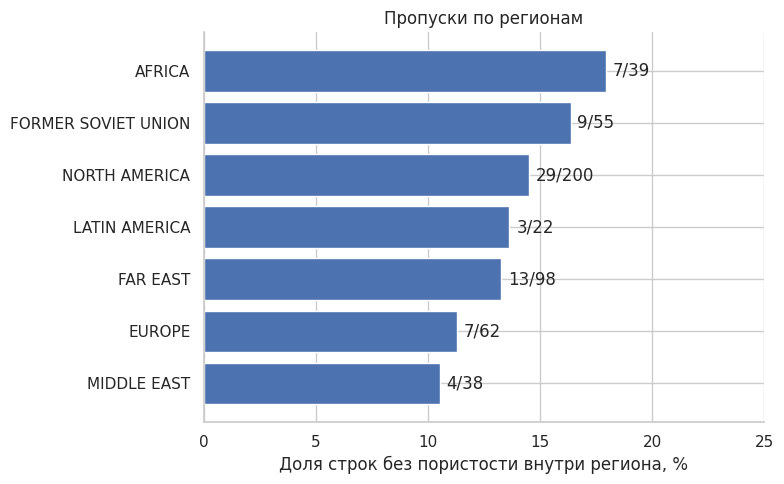

In [ ]:
subplot_result = plt.subplots(figsize=(8, 5))
figure = subplot_result[0]
axis = subplot_result[1]
axis.barh(missing_by_region.index, missing_by_region['missing_fraction'].mul(100), color='#4C72B0')
for position in range(len(missing_by_region)):
    region_row = missing_by_region.iloc[position]
    axis.text(region_row['missing_fraction'] * 100 + 0.3, position, f"{int(region_row['missing_count'])}/{int(region_row['total_count'])}", va='center')
axis.invert_yaxis()
axis.set_xlim(0, max(25, missing_by_region['missing_fraction'].max() * 100 + 7))
axis.set_xlabel('Доля строк без пористости внутри региона, %')
axis.set_title(f'Пропуски по регионам')
figure.tight_layout()
plt.show()

In [ ]:
missing_by_region

,total_count,missing_count,missing_fraction
region,,,
AFRICA,39,7,0.179487
FORMER SOVIET UNION,55,9,0.163636
NORTH AMERICA,200,29,0.145000
LATIN AMERICA,22,3,0.136364
FAR EAST,98,13,0.132653
EUROPE,62,7,0.112903
MIDDLE EAST,38,4,0.105263


- «где больше неизвестных значений?» и «где выше доля неизвестных?» — разные вопросы!
- нет видимой модели механизма сбора

In [ ]:
missing_group_summary = missingness_data.groupby('porosity_recorded')[['depth_ft', 'permeability_md']].agg(['count', 'median', 'min', 'max'])
missing_group_summary

depth_ft                     permeability_md         \
                         count  median  min    max           count median   
porosity_recorded                                                           
Пористость известна        442  6137.5  220  19888             442   79.5   
Пористость неизвестна       72  7589.5  920  17250              72  100.0   

                                      
                         min     max  
porosity_recorded                     
Пористость известна    0.010  7500.0  
Пористость неизвестна  0.001  4200.0

- Медиана глубины у объектов с пористостью 6137, без неё 7589.
- Медианы проницаемости - 79,5 и 100.
- Минимальная проницаемость равна 0,01 в первой группе и 0,001 во второй.

Итого - отбор только строк с пористостью меняет состав и наблюдаемый диапазон других измерений.

Нельзя сказать, что глубина вызывает пропуск. Обе группы могут различаться по литологии, региону или истории сбора

In [ ]:
lithology_missing_counts = pd.crosstab(missingness_data['lithology'], missingness_data['porosity_recorded'])
lithology_missing_counts = lithology_missing_counts.reindex(columns=missing_group_order, fill_value=0)
lithology_missing_shares = lithology_missing_counts.div(lithology_missing_counts.sum(axis=0), axis=1).mul(100)
common_lithology_order = eda_data['lithology'].value_counts().head(5).index.tolist()

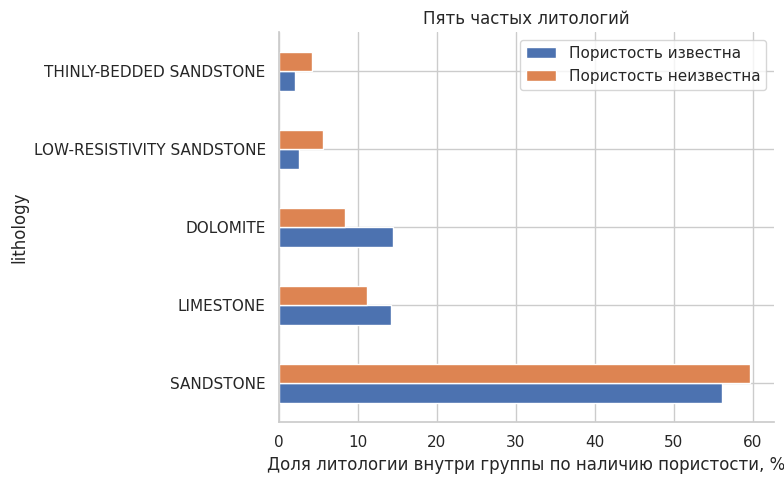

In [ ]:
subplot_result = plt.subplots(figsize=(8, 5))
figure = subplot_result[0]
axis = subplot_result[1]
lithology_missing_shares.loc[common_lithology_order].plot.barh(ax=axis)
axis.set_xlabel('Доля литологии внутри группы по наличию пористости, %')
axis.set_title('Пять частых литологий')
axis.legend()
figure.tight_layout()
plt.show()

In [ ]:
lithology_missing_counts.loc[common_lithology_order]

porosity_recorded,Пористость известна,Пористость неизвестна
lithology,,
SANDSTONE,248,43
LIMESTONE,63,8
DOLOMITE,64,6
LOW-RESISTIVITY SANDSTONE,11,4
THINLY-BEDDED SANDSTONE,9,3


Группы содержат смеси литологий, а не один тип породы. Совместные различия состава ещё одна причина не интерпретировать разницу медиан глубины как причинный эффект наличия измерения

### Состав выборки

#### Строки и месторождения имеют разные веса

Посмотрим распределение регионов двумя способами: по всем строкам и по ключам месторождений

In [ ]:
region_row_counts = eda_data['region'].value_counts()
region_order = region_row_counts.index.tolist()
field_region_conflicts = eda_data.groupby(field_key)['region'].nunique(dropna=False)
field_region_data = eda_data.drop_duplicates(subset=field_key)
region_field_counts = field_region_data['region'].value_counts().reindex(region_order, fill_value=0)

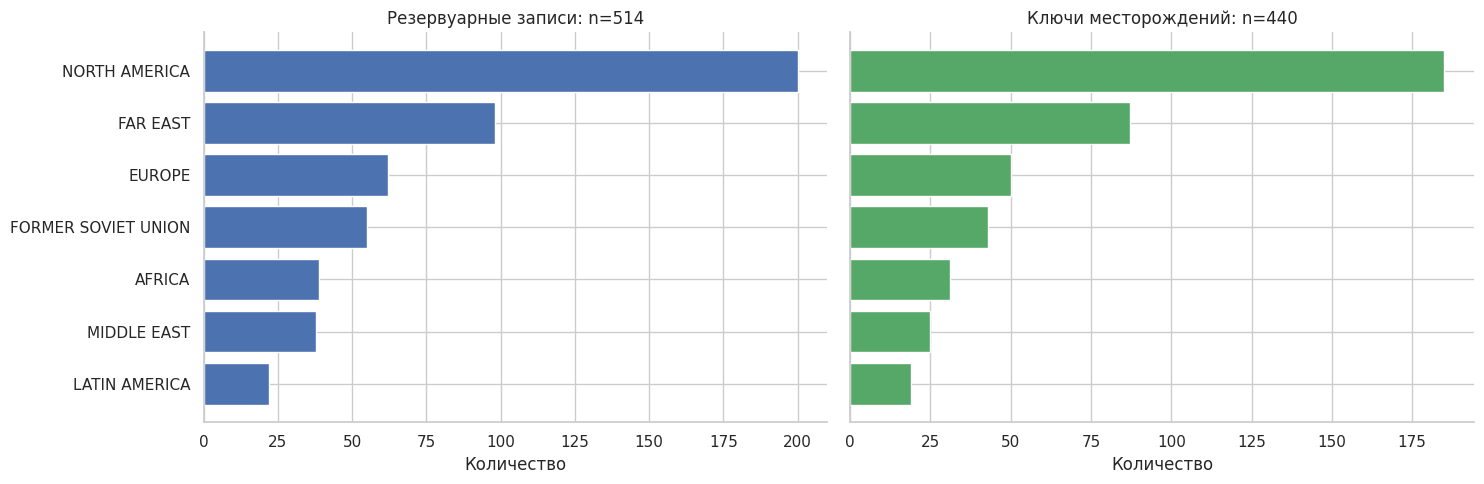

In [ ]:
subplot_result = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
figure = subplot_result[0]
axes = subplot_result[1]
axes[0].barh(region_order, region_row_counts.loc[region_order], color='#4C72B0')
axes[1].barh(region_order, region_field_counts.loc[region_order], color='#55A868')
axes[0].invert_yaxis()
axes[0].set_title(f'Резервуарные строки: n={len(eda_data)}')
axes[1].set_title(f'Ключи месторождений: n={len(field_region_data)}')
for axis in axes:
    axis.set_xlabel('Количество')
figure.tight_layout()
plt.show()

#### География

Используем диаграмму долгота–широта.

Сгруппируем одинаковые координаты, чтобы не потерять совпадающие точки. Площадь маркера пропорциональна числу резервуарных записей в точке

In [ ]:
coordinate_counts = eda_data.groupby(coordinate_columns, dropna=False).size().rename('reservoir_rows').reset_index()
north_of_65_count = int(eda_data['latitude'].gt(65).sum())

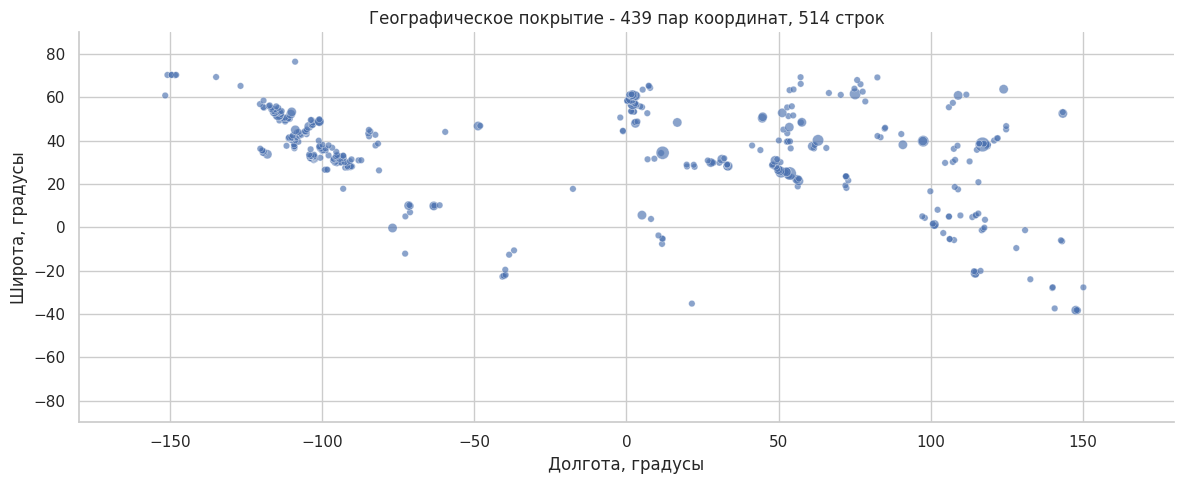

In [ ]:
subplot_result = plt.subplots(figsize=(12, 5))
figure = subplot_result[0]
axis = subplot_result[1]
axis.scatter(coordinate_counts['longitude'], coordinate_counts['latitude'], s=coordinate_counts['reservoir_rows'].mul(22), alpha=0.65, color='#4C72B0', edgecolors='white', linewidths=0.3)
axis.set_xlim(-180, 180)
axis.set_ylim(-90, 90)
axis.set_xlabel('Долгота, градусы')
axis.set_ylabel('Широта, градусы')
axis.set_title(f'Географическое покрытие - {len(coordinate_counts)} пар координат, {len(eda_data)} строк')
figure.tight_layout()
plt.show()

Данные распределены по нескольким географическим скоплениям, поэтому близкие объекты могут иметь общую геологию и историю сбора.

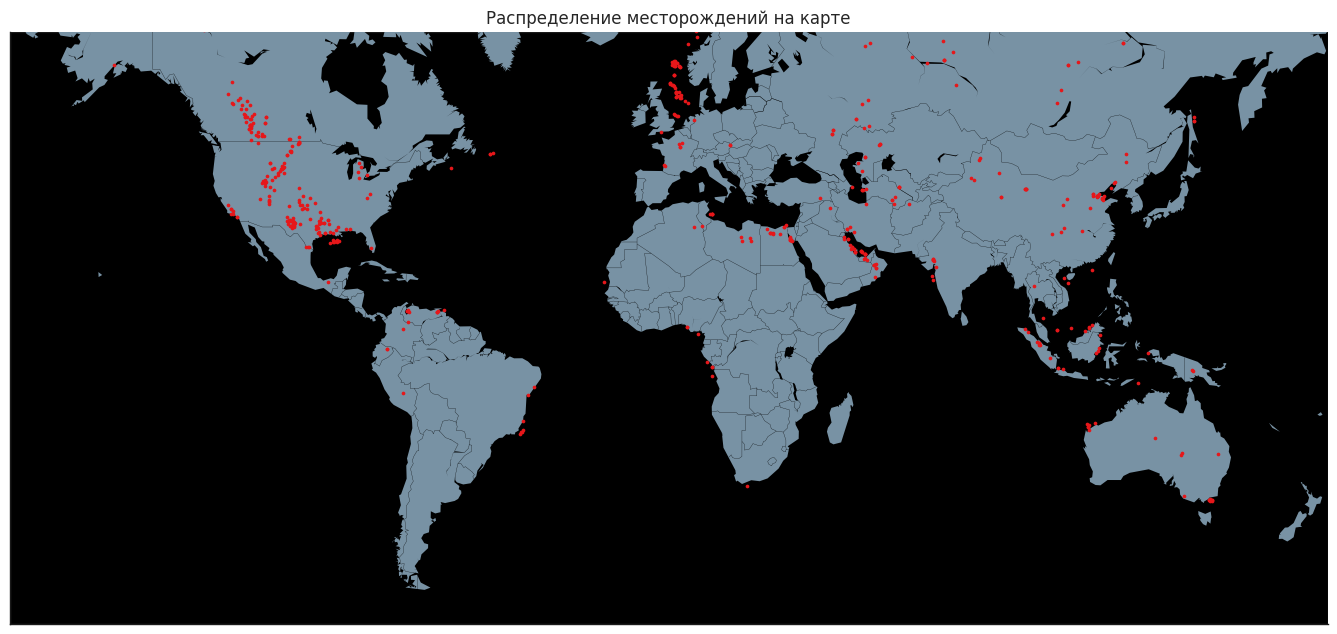

In [ ]:
plt.figure(1, figsize=(17, 10))

# Mercator of World
m1 = Basemap(
    projection='merc',
    llcrnrlat=-60,
    urcrnrlat=65,
    llcrnrlon=-180,
    urcrnrlon=180,
    lat_ts=0,
    resolution='c',
)

m1.fillcontinents(color='#7892A4',lake_color='#000000') # dark grey land, black lakes
m1.drawmapboundary(fill_color='#000000')                # black background
m1.drawcountries(linewidth=0.2, color="#000000")        # thin white line for country borders

# Plot the data
mxy = m1(eda_data["longitude"].tolist(), eda_data["latitude"].tolist())
m1.scatter(mxy[0], mxy[1], s=7, c="#E6171A", lw=0, alpha=1, zorder=5)

plt.title("Распределение месторождений на карте")
plt.show()

#### Категориальный таргет и редкие классы

Известны 442 значения тектонического режима. Покажем частоты всех известных категорий без кодирования числами и рядом доли от 442 известных и от 514 всех строк. Отдельно сохраним количество неизвестных значений.

In [ ]:
tectonic_counts = eda_data['tectonic_regime'].value_counts()
tectonic_summary = tectonic_counts.rename('known_count').to_frame()
tectonic_summary['share_of_known_pct'] = tectonic_counts.div(eda_data['tectonic_regime'].notna().sum()).mul(100)
tectonic_summary['share_of_all_rows_pct'] = tectonic_counts.div(len(eda_data)).mul(100)

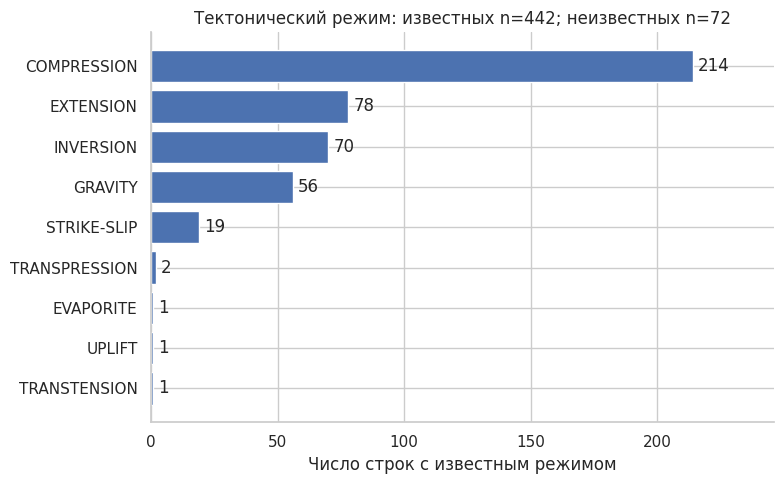

In [ ]:
subplot_result = plt.subplots(figsize=(8, 5))
figure = subplot_result[0]
axis = subplot_result[1]
axis.barh(tectonic_counts.index, tectonic_counts.values, color='#4C72B0')
for position in range(len(tectonic_counts)):
    axis.text(tectonic_counts.iloc[position] + 2, position, str(tectonic_counts.iloc[position]), va='center')
axis.invert_yaxis()
axis.set_xlim(0, tectonic_counts.max() * 1.15)
axis.set_xlabel('Число строк с известным режимом')
axis.set_title(f'Тектонический режим: известных n={tectonic_counts.sum()}; неизвестных n={tectonic_missing_mask.sum()}')
figure.tight_layout()
plt.show()

In [ ]:
tectonic_summary

,known_count,share_of_known_pct,share_of_all_rows_pct
tectonic_regime,,,
COMPRESSION,214,48.416290,41.634241
EXTENSION,78,17.647059,15.175097
INVERSION,70,15.837104,13.618677
GRAVITY,56,12.669683,10.894942
STRIKE-SLIP,19,4.298643,3.696498
TRANSPRESSION,2,0.452489,0.389105
EVAPORITE,1,0.226244,0.194553
UPLIFT,1,0.226244,0.194553
TRANSTENSION,1,0.226244,0.194553


Фиксируем выраженный дисбаланс и отсутствие надежной базы для выводов о самых редких группах

In [ ]:
pd.crosstab(eda_data['region'], eda_data['tectonic_regime'], margins=True).style.background_gradient(cmap='summer_r')

tectonic_regime,COMPRESSION,EVAPORITE,EXTENSION,GRAVITY,INVERSION,STRIKE-SLIP,TRANSPRESSION,TRANSTENSION,UPLIFT,All
region,,,,,,,,,,
AFRICA,2,1,17,5,4,3,0,0,0,32
EUROPE,3,0,29,3,20,0,0,0,0,55
FAR EAST,19,0,23,3,34,5,0,1,0,85
FORMER SOVIET UNION,36,0,0,0,5,3,2,0,0,46
LATIN AMERICA,8,0,3,4,1,3,0,0,0,19
MIDDLE EAST,24,0,0,9,1,0,0,0,0,34
NORTH AMERICA,122,0,6,32,5,5,0,0,1,171
All,214,1,78,56,70,19,2,1,1,442


Кардинальность не мера полезности столбца! высокая кардинальность может отражать идентичность объекта, структуру источника или содержательное разнообразие

### Распределения



#### Число измерений и статистики

Сводная таблица включает количество известных значений, среднее, медиану и квантили. Пропуски не считаем нулями

In [ ]:
measurement_summary = eda_data[measurement_columns].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).T
measurement_summary['missing_count'] = eda_data[measurement_columns].isna().sum()
measurement_summary['iqr'] = measurement_summary['75%'].sub(measurement_summary['25%'])
measurement_summary.round(3)

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,missing_count,iqr
depth_ft,514.0,6707.280,3613.720,220.000,500.000,3909.75,6393.5,9116.25,13250.0,16481.8,19888.0,0,5206.50
gross_thickness_ft,514.0,783.679,1424.954,11.000,32.390,140.00,328.0,753.75,3052.5,7656.6,12500.0,0,613.75
net_pay_thickness_ft,514.0,190.772,271.927,0.000,7.000,43.25,101.0,225.00,611.0,1261.0,2976.0,0,181.75
porosity_pct,442.0,17.930,7.554,1.100,2.787,12.00,17.9,24.00,30.0,34.0,55.0,72,12.00
permeability_md,514.0,464.760,1001.308,0.001,0.046,10.00,83.0,400.00,2151.2,5000.0,7500.0,0,390.00


#### Отдельно рассмотрим пористость

Построим гистограммы, варьируя число интервалов

In [ ]:
porosity_values = eda_data['porosity_pct'].dropna()
porosity_bin_edges_coarse = np.linspace(0, 60, 11)
porosity_bin_edges_fine = np.linspace(0, 60, 41)

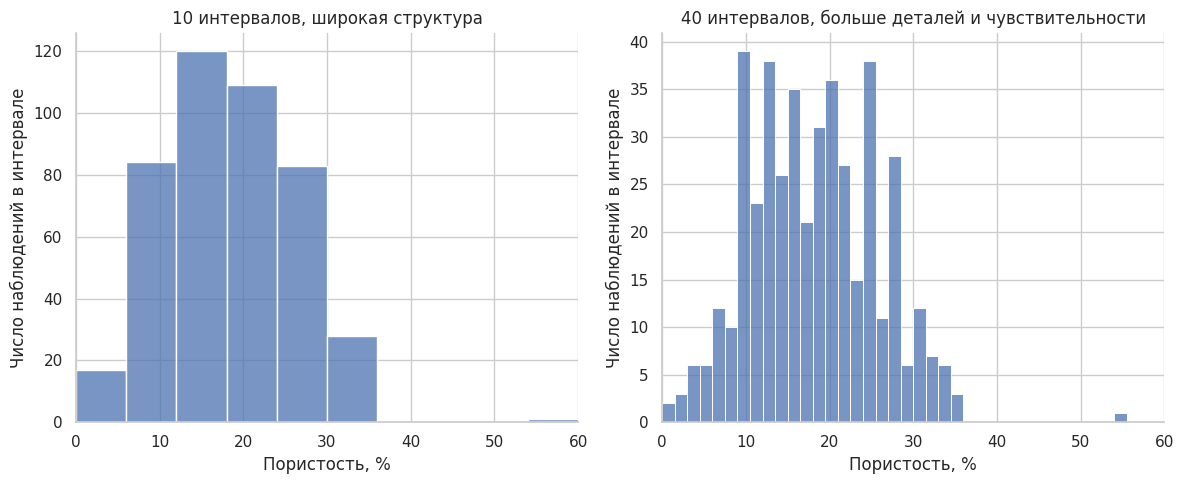

In [ ]:
subplot_result = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
figure = subplot_result[0]
axes = subplot_result[1]
sns.histplot(x=porosity_values, bins=porosity_bin_edges_coarse, color='#4C72B0', ax=axes[0])
sns.histplot(x=porosity_values, bins=porosity_bin_edges_fine, color='#4C72B0', ax=axes[1])
axes[0].set_title('10 интервалов, широкая структура')
axes[1].set_title('40 интервалов, больше деталей и чувствительности')
for axis in axes:
    axis.set_xlim(0, 60)
    axis.set_xlabel('Пористость, %')
    axis.set_ylabel('Число наблюдений в интервале')
figure.tight_layout()
plt.show()

- Основной массив пористости расположен существенно ниже 55%, и высокая точка отделена от него при обоих разбиениях.
- Высота столбца - число строк в бине, чтобы оценить долю выше порога или прочитать медиану без выбора интервалов, используем ECDF

In [ ]:
porosity_thresholds = pd.DataFrame({'threshold_pct': [10, 20, 30]})
porosity_thresholds['fraction_at_or_below'] = [porosity_values.le(threshold).mean() for threshold in porosity_thresholds['threshold_pct']]
porosity_thresholds['fraction_above'] = 1 - porosity_thresholds['fraction_at_or_below']

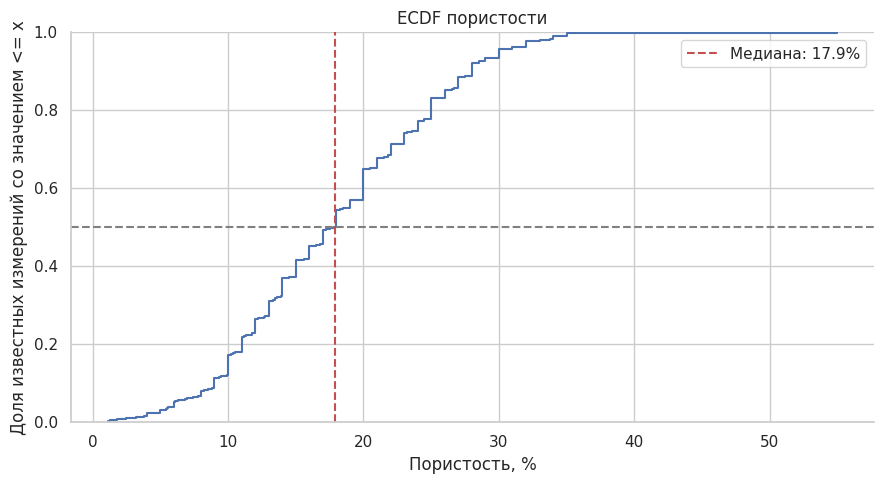

In [ ]:
subplot_result = plt.subplots(figsize=(9, 5))
figure = subplot_result[0]
axis = subplot_result[1]
sns.ecdfplot(x=porosity_values, ax=axis, color='#4C72B0')
axis.axhline(0.5, color='gray', linestyle='--')
axis.axvline(porosity_values.median(), color='#C44E52', linestyle='--', label=f'Медиана: {porosity_values.median():.1f}%')
axis.set_xlabel('Пористость, %')
axis.set_ylabel('Доля известных измерений со значением <= x')
axis.set_title(f'ECDF пористости')
axis.legend()
figure.tight_layout()
plt.show()

- ECDF позволяет читать доли непосредственно по порогам, без выбора интервалов и сглаживания
- Медиана 17,9% относится к известным измерениям

In [ ]:
permeability_values = eda_data['permeability_md'].dropna()
permeability_linear_edges = np.linspace(permeability_values.min(), permeability_values.max(), 31)
permeability_log_edges = np.geomspace(permeability_values.min(), permeability_values.max(), 31)

#### Проницаемость

Слева интервалы равной ширины в mD, справа равной ширины по логарифму

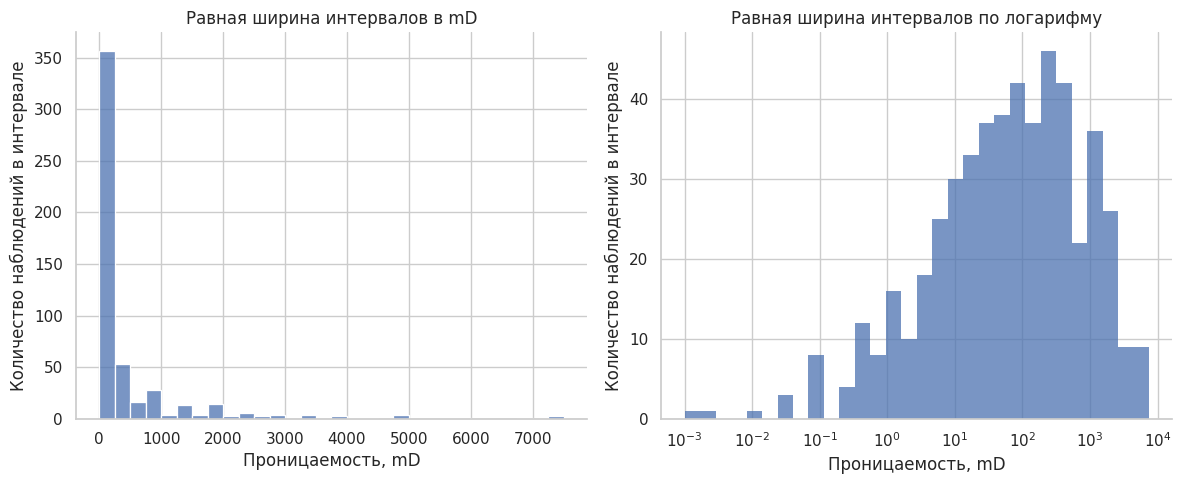

In [ ]:
subplot_result = plt.subplots(1, 2, figsize=(12, 5))
figure = subplot_result[0]
axes = subplot_result[1]
sns.histplot(x=permeability_values, bins=permeability_linear_edges, color='#4C72B0', ax=axes[0])
sns.histplot(x=permeability_values, bins=permeability_log_edges, color='#4C72B0', ax=axes[1])
axes[1].set_xscale('log')
axes[0].set_title('Равная ширина интервалов в mD')
axes[1].set_title('Равная ширина интервалов по логарифму')
for axis in axes:
    axis.set_xlabel('Проницаемость, mD')
    axis.set_ylabel('Количество наблюдений в интервале')
figure.tight_layout()
plt.show()

- Линейная шкала показывает абсолютный размер хвоста, но сжимает малые значения. Логарифмическая раскрывает несколько порядков величины.
Оба изображения корректны, если явно назвать шкалу, интервалы и статистику на оси y.
- Сильная асимметрия не означает, что данные нужно сделать нормальными. Пока фиксируем широкий диапазон, хвост и необходимость смотреть на графики в нескольких масштабах.

In [ ]:
most_frequent_measurements = []
for column in ['porosity_pct', 'permeability_md']:
    value_counts = eda_data[column].value_counts().head(8)
    for value in value_counts.index:
        most_frequent_measurements.append({'measurement': column, 'value': value, 'count': int(value_counts.loc[value])})
pd.DataFrame(most_frequent_measurements)

,measurement,value,count
0,porosity_pct,20.0,35
1,porosity_pct,25.0,24
2,porosity_pct,10.0,23
3,porosity_pct,14.0,20
4,porosity_pct,18.0,20
5,porosity_pct,15.0,19
6,porosity_pct,11.0,17
7,porosity_pct,17.0,16
8,permeability_md,1000.0,20
9,permeability_md,100.0,18


- В числовых измерениях есть часто повторяющиеся значения - это повод проверить точность записи, округление и наличие подставленных типичных оценок. Повторы сами по себе не доказывают ошибку или искусственное происхождение набора.

Не считаем числовую переменную категориальной только потому, что значений немного!

#### Boxplot

Стандартное правило использует границы `Q1 - 1.5 * IQR` и `Q3 + 1.5 * IQR`, все, что за границами необычно, но не обязательно физически невозможно или неверно. Для длинного правого хвоста выбросов может быть много.

In [ ]:
iqr_review_rows = []

for column in measurement_columns:
    observed_values = eda_data[column].dropna()
    first_quartile = observed_values.quantile(0.25)
    third_quartile = observed_values.quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_fence = first_quartile - 1.5 * interquartile_range
    upper_fence = third_quartile + 1.5 * interquartile_range
    review_mask = observed_values.lt(lower_fence) | observed_values.gt(upper_fence)
    iqr_review_rows.append({
        'measurement': column,
        'observed_count': len(observed_values),
        'lower_fence': lower_fence,
        'upper_fence': upper_fence,
        'candidate_count': int(review_mask.sum()),
        'candidate_pct': review_mask.mean() * 100
    })

iqr_review_summary = pd.DataFrame(iqr_review_rows)
iqr_review_summary.round(3)

,measurement,observed_count,lower_fence,upper_fence,candidate_count,candidate_pct
0,depth_ft,514,-3900.000,16926.000,5,0.973
1,gross_thickness_ft,514,-780.625,1674.375,49,9.533
2,net_pay_thickness_ft,514,-229.375,497.625,43,8.366
3,porosity_pct,442,-6.000,42.000,1,0.226
4,permeability_md,514,-575.000,985.000,80,15.564


In [ ]:
high_porosity_records = eda_data.loc[eda_data['porosity_pct'].gt(50)]

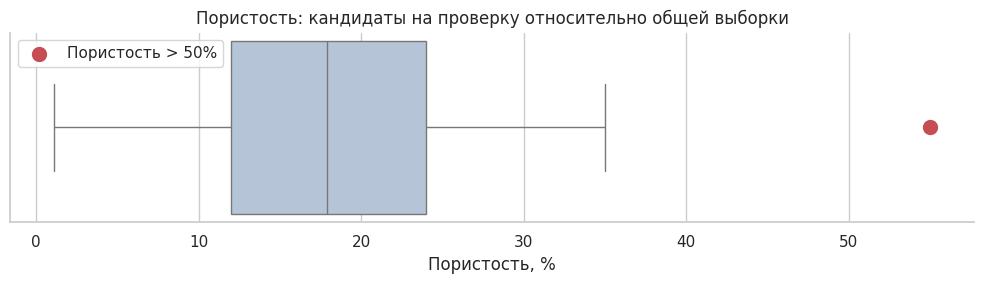

In [ ]:
subplot_result = plt.subplots(figsize=(10, 3))
figure = subplot_result[0]
axis = subplot_result[1]
sns.boxplot(x=porosity_values, color='#AFC5DD', ax=axis)
axis.scatter(high_porosity_records['porosity_pct'], np.zeros(len(high_porosity_records)), s=100, color='#C44E52', zorder=4, label='Пористость > 50%')
axis.set_xlabel('Пористость, %')
axis.set_title(f'Пористость: кандидаты на проверку относительно общей выборки')
axis.legend(loc='upper left')
figure.tight_layout()
plt.show()

In [ ]:
high_porosity_records[reservoir_key + ['lithology', 'depth_ft', 'porosity_pct', 'permeability_md', 'gross_thickness_ft', 'net_pay_thickness_ft']]

,country,field_name,reservoir_unit,lithology,depth_ft,porosity_pct,permeability_md,gross_thickness_ft,net_pay_thickness_ft
401,USA,SOUTH BELRIDGE,BELRIDGE DIATOMITE (MONTEREY-ETCHEGOIN),DIATOMITE,600,55.0,1.5,1000.0,900.0


Точка 55% принадлежит SOUTH BELRIDGE, резервуарной единице BELRIDGE DIATOMITE (MONTEREY-ETCHEGOIN). Объект относится к редкой литологии, представленной одной строкой.

[Публикация о Belridge Diatomite](https://www.osti.gov/biblio/7032942) описывает высокую пористость и низкую проницаемость, значения пористости около 55% для этого резервуара правдоподобны.

Нельзя удалить точку потому, что она выходит за усы boxplot

### Сравнение групп

#### Пористость по распространённым литологиям

Сначала считаем общее число строк каждой литологии и число известных значений пористости. Для основного графика берём группы с не менее чем 20 известными измерениями - SANDSTONE, LIMESTONE и DOLOMITE.

Boxplot показывает медиану и квартили, отдельные точки помогают увидеть фактическую опору распределения.

In [ ]:
lithology_summary = eda_data.groupby('lithology')['porosity_pct'].agg(['size', 'count', 'median', 'mean', 'min', 'max'])
lithology_summary.columns = ['total_rows', 'known_porosity_count', 'median_porosity_pct', 'mean_porosity_pct', 'min_porosity_pct', 'max_porosity_pct']
lithology_summary['missing_porosity_count'] = lithology_summary['total_rows'].sub(lithology_summary['known_porosity_count'])
lithology_summary = lithology_summary.sort_values('total_rows', ascending=False)
comparison_lithologies = lithology_summary.loc[lithology_summary['known_porosity_count'].ge(20)].sort_values('median_porosity_pct').index.tolist()
lithology_comparison_data = eda_data.loc[eda_data['lithology'].isin(comparison_lithologies) & eda_data['porosity_pct'].notna()].copy()

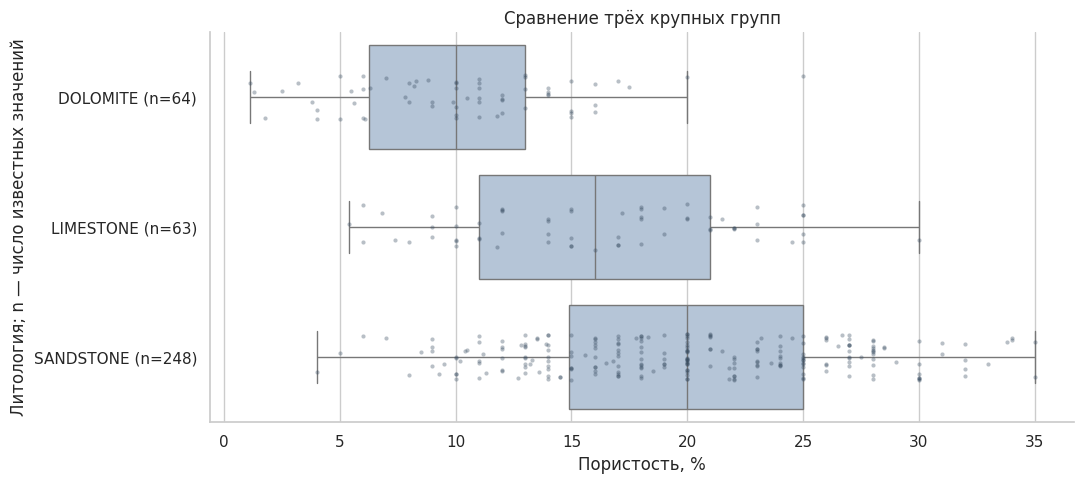

In [ ]:
np.random.seed(42)

subplot_result = plt.subplots(figsize=(11, 5))
figure = subplot_result[0]
axis = subplot_result[1]
sns.boxplot(data=lithology_comparison_data, x='porosity_pct', y='lithology', order=comparison_lithologies, color='#AFC5DD', showfliers=False, ax=axis)
sns.stripplot(data=lithology_comparison_data, x='porosity_pct', y='lithology', order=comparison_lithologies, color='#34495E', alpha=0.35, size=3, jitter=0.18, ax=axis)
axis.set_yticks(range(len(comparison_lithologies)))
axis.set_yticklabels([f"{category} (n={int(lithology_summary.loc[category, 'known_porosity_count'])})" for category in comparison_lithologies])
axis.set_xlabel('Пористость, %')
axis.set_ylabel('Литология; n — число известных значений')
axis.set_title('Сравнение трёх крупных групп')
figure.tight_layout()
plt.show()


положение распределений различается, но они не превращаются в три непересекающихся диапазона

#### Размер группы и форма распределения

Сравним те же группы через гистограммы и ECDF. Гистограммы имеют общие границы интервалов и нормируются отдельно внутри каждой литологии. Без независимой нормировки самая большая группа SANDSTONE могла бы доминировать просто из-за числа строк.

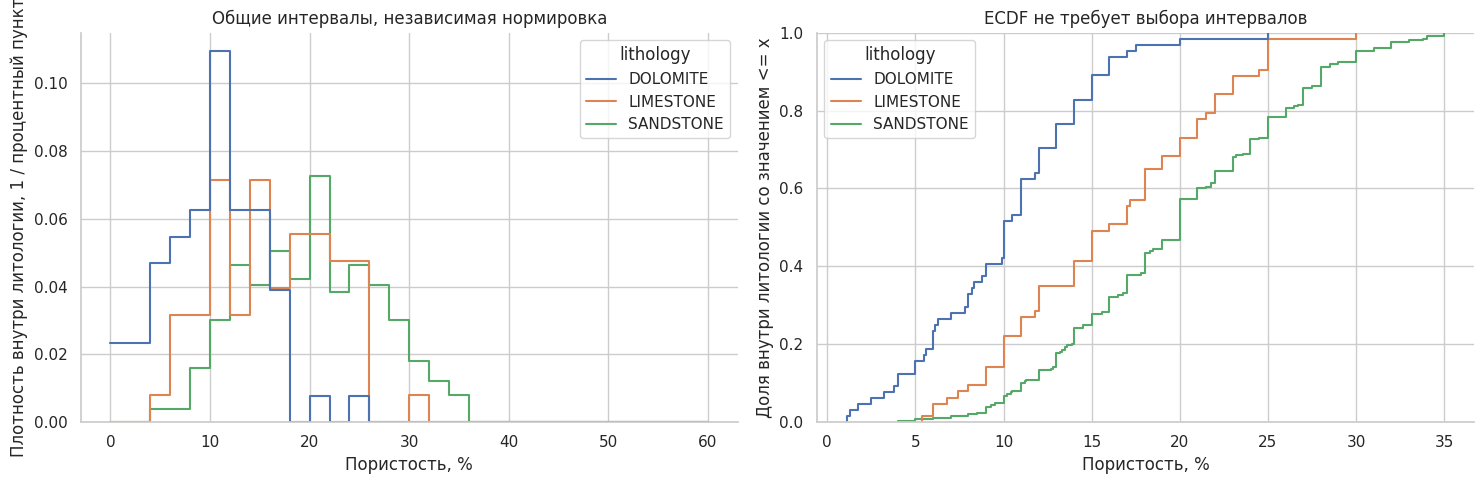

In [ ]:
common_porosity_edges = np.arange(0, 62, 2)
subplot_result = plt.subplots(1, 2, figsize=(15, 5))
figure = subplot_result[0]
axes = subplot_result[1]
sns.histplot(
    data=lithology_comparison_data,
    x='porosity_pct',
    hue='lithology',
    hue_order=comparison_lithologies,
    bins=common_porosity_edges,
    stat='density',
    common_norm=False,
    common_bins=True,
    element='step',
    fill=False,
    ax=axes[0],
)
sns.ecdfplot(data=lithology_comparison_data, x='porosity_pct', hue='lithology', hue_order=comparison_lithologies, ax=axes[1])
axes[0].set_ylabel('Плотность внутри литологии, 1 / процентный пункт')
axes[0].set_title('Общие интервалы, независимая нормировка')
axes[1].set_ylabel('Доля внутри литологии со значением <= x')
axes[1].set_title('ECDF не требует выбора интервалов')
for axis in axes:
    axis.set_xlabel('Пористость, %')
figure.tight_layout()
plt.show()

- Здесь сравниваем форму и положение известных измерений - одинаковая нормировка делает группы визуально сопоставимыми.
- Различия ECDF подтверждают, что сравнение не исчерпывается одним пиком.

### Связи измерений



#### Глубина и пористость

Отбираем только строки, где известны обе величины, cмотрим направление, разброс, отдельные точки, неодинаковую плотность наблюдений и области, где данных мало

In [ ]:
depth_porosity_data = eda_data.loc[eda_data[['depth_ft', 'porosity_pct']].notna().all(axis=1), reservoir_key + ['depth_ft', 'porosity_pct', 'lithology']].copy()

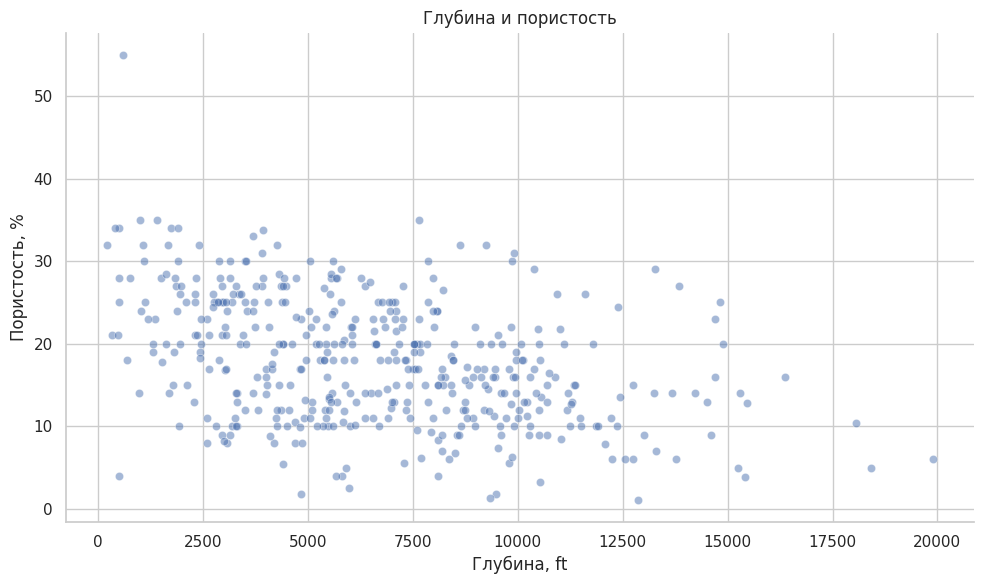

In [ ]:
subplot_result = plt.subplots(figsize=(10, 6))
figure = subplot_result[0]
axis = subplot_result[1]
sns.scatterplot(data=depth_porosity_data, x='depth_ft', y='porosity_pct', alpha=0.5, s=35, color='#4C72B0', ax=axis)
axis.set_xlabel('Глубина, ft')
axis.set_ylabel('Пористость, %')
axis.set_title(f'Глубина и пористость')
figure.tight_layout()
plt.show()

- В облаке точек видна тенденция к меньшей пористости при большей глубине, но разброс велик, по одной глубине нельзя прочитать точное значение пористости.
- Отдельная высокая пористость относится к диатомиту, который уже рассматривали.
- На больших глубинах наблюдений меньше, чем в центральной области, поэтому впечатление о связи там опирается на меньшую базу.

#### Ковариация и корреляция

- Ковариация описывает совместные отклонения от средних. Положительный знак означает, что большие относительно своих средних значения чаще сочетаются, отрицательный — что направления чаще противоположны. Она не предсказывает величину изменения одной переменной при изменении другой.


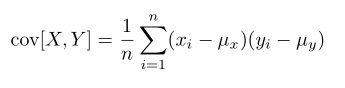

- корреляция Пирсона - нормированная ковариация: описательный коэффициент линейной связи от -1 до 1

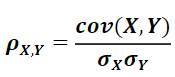

- Корреляция Спирмена - корреляция рангов, описывает монотонную связь

In [ ]:
depth_values_ft = depth_porosity_data['depth_ft']
depth_values_m = depth_values_ft.mul(0.3048)
paired_porosity_values = depth_porosity_data['porosity_pct']
unit_comparison = pd.DataFrame({'depth_unit': ['ft', 'm'], 'sample_covariance': [depth_values_ft.cov(paired_porosity_values), depth_values_m.cov(paired_porosity_values)], 'pearson': [depth_values_ft.corr(paired_porosity_values), depth_values_m.corr(paired_porosity_values)], 'spearman': [depth_values_ft.corr(paired_porosity_values, method='spearman'), depth_values_m.corr(paired_porosity_values, method='spearman')]})
unit_comparison

,depth_unit,sample_covariance,pearson,spearman
0,ft,-10852.923213,-0.402149,-0.392593
1,m,-3307.970995,-0.402149,-0.392593


Ковариация меняется в 0,3048 раза, потому что глубина выражена в других единицах. Направление связи сохраняется.
Пирсон около -0,402 и Спирмен около -0,393 совпадают до округления между единицами.

- Ни ковариация, ни корреляция не устанавливают причинно-следственной связи
- Отсутствие линейной корреляции не означает отсутствие взаимосвязи. Возможно взаимосвязь есть, но она нелинейна
- На коэффициент корреляции Пирсона существенное влияние оказывают выбросы


#### Пористость и проницаемость - влияние масштаба

Сравним одни и те же 442 пары на линейной и логарифмической оси проницаемости. Все значения проницаемости в выбранной паре положительны, коэффициент Пирсона по `log10(permeability)` уже характеристика другой числовой переменной - он не равен Пирсону по исходным mD

In [ ]:
porosity_permeability_data = eda_data.loc[eda_data[['porosity_pct', 'permeability_md']].notna().all(axis=1), reservoir_key + ['porosity_pct', 'permeability_md', 'lithology']].copy()

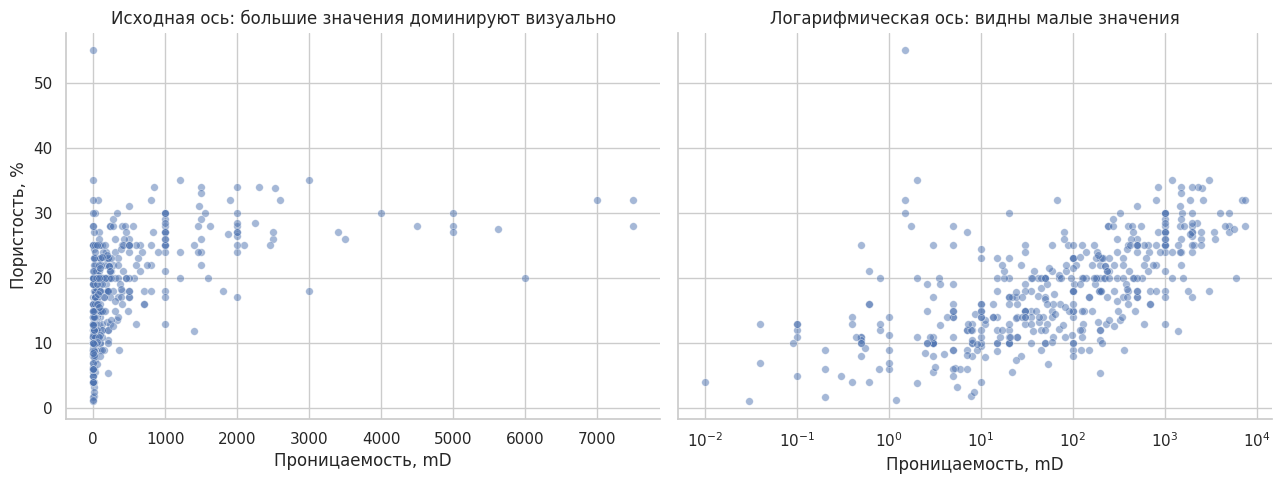

In [ ]:
subplot_result = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
figure = subplot_result[0]
axes = subplot_result[1]

for axis in axes:
    sns.scatterplot(data=porosity_permeability_data, x='permeability_md', y='porosity_pct', alpha=0.5, s=30, color='#4C72B0', ax=axis)
    axis.set_xlabel('Проницаемость, mD')
    axis.set_ylabel('Пористость, %')
axes[0].set_title('Исходная ось: большие значения доминируют визуально')
axes[1].set_xscale('log')
axes[1].set_title('Логарифмическая ось: видны малые значения')
figure.tight_layout()
plt.show()

In [ ]:
permeability_association = pd.Series({'pearson_original': porosity_permeability_data['porosity_pct'].corr(porosity_permeability_data['permeability_md']), 'spearman_original': porosity_permeability_data['porosity_pct'].corr(porosity_permeability_data['permeability_md'], method='spearman'), 'pearson_log10_permeability': porosity_permeability_data['porosity_pct'].corr(np.log10(porosity_permeability_data['permeability_md']))}, name='coefficient')
permeability_association

,coefficient
pearson_original,0.473850
spearman_original,0.657703
pearson_log10_permeability,0.612895


Пирсон по исходной проницаемости около 0,474, Спирмен - 0,658, Пирсон по логарифму проницаемости - 0,613. Согласованное направление и разные величины коэффициентов показывают, что один линейный коэффициент не исчерпывает структуру связи на широком диапазоне значений.

Разные коэффициенты отвечают на разные вопросы. Мы фиксируем положительную ассоциацию, нелинейный масштаб и большой разброс

#### Общая связь и связи внутри групп

Группы могут иметь разные положения облаков точек. Связь между групповыми центрами и связь внутри каждой группы не одно и то же.

Покажем глубину и пористость отдельно в трёх крупных литологиях с общими пределами осей. Размеры групп и коэффициенты считаем на одних и тех же полных парах

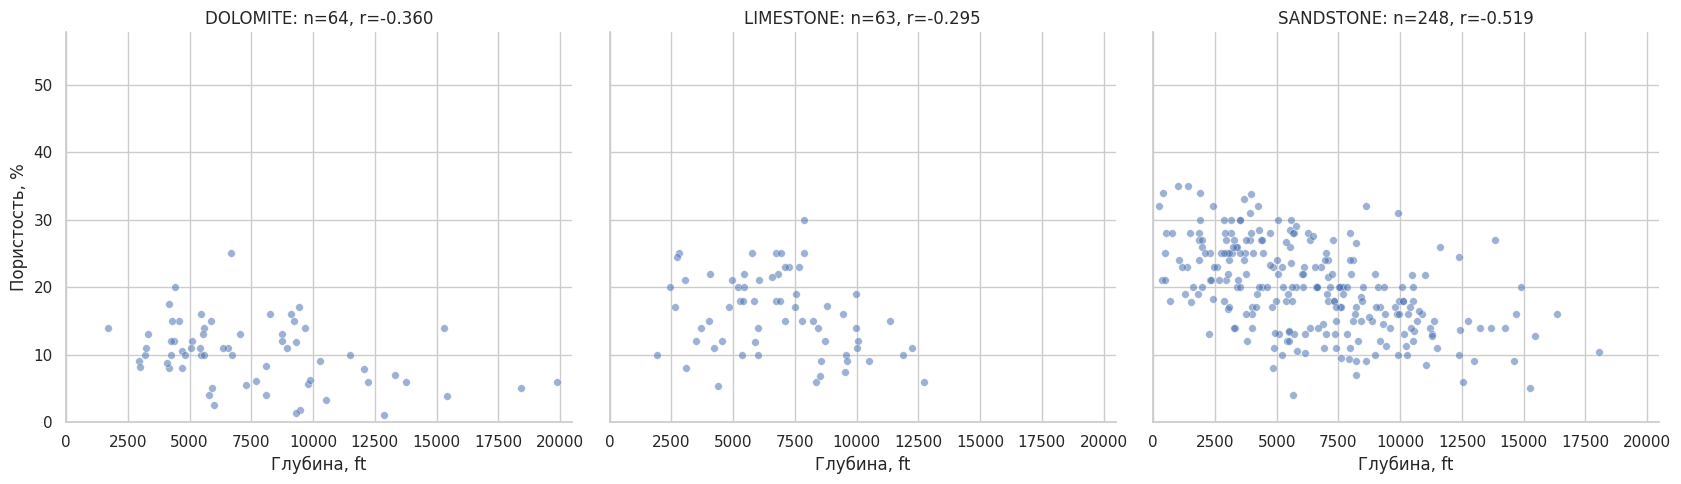

In [ ]:
group_association_rows = []
subplot_result = plt.subplots(1, len(comparison_lithologies), figsize=(17, 5), sharex=True, sharey=True, squeeze=False)
figure = subplot_result[0]
axes = subplot_result[1][0]
for position in range(len(comparison_lithologies)):
    category = comparison_lithologies[position]
    group_data = depth_porosity_data.loc[depth_porosity_data['lithology'].eq(category)]
    group_pearson = group_data['depth_ft'].corr(group_data['porosity_pct'])
    group_spearman = group_data['depth_ft'].corr(group_data['porosity_pct'], method='spearman')
    group_association_rows.append({'lithology': category, 'paired_count': len(group_data), 'pearson': group_pearson, 'spearman': group_spearman, 'median_depth_ft': group_data['depth_ft'].median(), 'median_porosity_pct': group_data['porosity_pct'].median()})
    sns.scatterplot(data=group_data, x='depth_ft', y='porosity_pct', alpha=0.55, s=30, color='#4C72B0', ax=axes[position])
    axes[position].set_title(f'{category}: n={len(group_data)}, r={group_pearson:.3f}')
    axes[position].set_xlim(0, depth_porosity_data['depth_ft'].max() * 1.03)
    axes[position].set_ylim(0, depth_porosity_data['porosity_pct'].max() * 1.05)
    axes[position].set_xlabel('Глубина, ft')
    axes[position].set_ylabel('Пористость, %')
figure.tight_layout()
plt.show()

In [ ]:
group_association_summary = pd.DataFrame(group_association_rows)
group_association_summary

,lithology,paired_count,pearson,spearman,median_depth_ft,median_porosity_pct
0,DOLOMITE,64,-0.360475,-0.353585,6605.5,10.0
1,LIMESTONE,63,-0.294634,-0.288452,6825.0,16.0
2,SANDSTONE,248,-0.519284,-0.532221,5935.0,20.0


Направление в этих группах остаётся отрицательным, но величины отличаются - агрегированный коэффициент скрывает неоднородность. Для дальнейшей работы сохраняем вопрос о групповых различиях, а не только одну общую корреляцию.

#### Матрица корреляций

Теперь строим компактные матрицы по пяти физическим измерениям. Идентификаторы, координаты и категориальные переменные в них не включаем.


In [ ]:
measurement_presence = eda_data[measurement_columns].notna().astype(int)
pair_counts = measurement_presence.T.dot(measurement_presence)
pearson_matrix = eda_data[measurement_columns].corr(method='pearson')
spearman_matrix = eda_data[measurement_columns].corr(method='spearman')
short_measurement_labels = ['Глубина', 'Общая толщина', 'Полезная толщина', 'Пористость', 'Проницаемость']

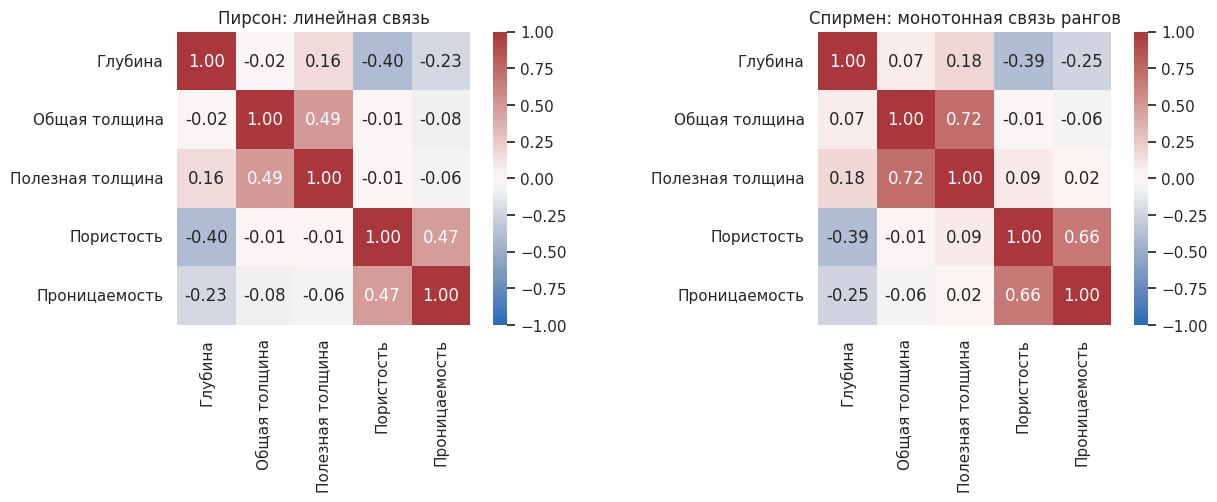

In [ ]:
subplot_result = plt.subplots(1, 2, figsize=(13, 5))
figure = subplot_result[0]
axes = subplot_result[1]
sns.heatmap(pearson_matrix, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, center=0, square=True, xticklabels=short_measurement_labels, yticklabels=short_measurement_labels, ax=axes[0])
sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, center=0, square=True, xticklabels=short_measurement_labels, yticklabels=short_measurement_labels, ax=axes[1])
axes[0].set_title('Пирсон: линейная связь')
axes[1].set_title('Спирмен: монотонная связь рангов')
figure.tight_layout()
plt.show()

-  Пористость связана с глубиной и проницаемостью, а общей и полезной толщине соответствует положительная ассоциация.
- Низкая корреляция Пирсона не исключает нелинейность или различия подгрупп, а высокий коэффициент не гарантирует полезности для будущей задачи и может отражать дубли.

Наблюдения фиксируем как гипотезы для дальнейшей проверки.

#### Phik

interval columns not set, guessing: ['export_index', 'record_id', 'latitude', 'longitude', 'depth_ft', 'gross_thickness_ft', 'net_pay_thickness_ft', 'porosity_pct', 'permeability_md']


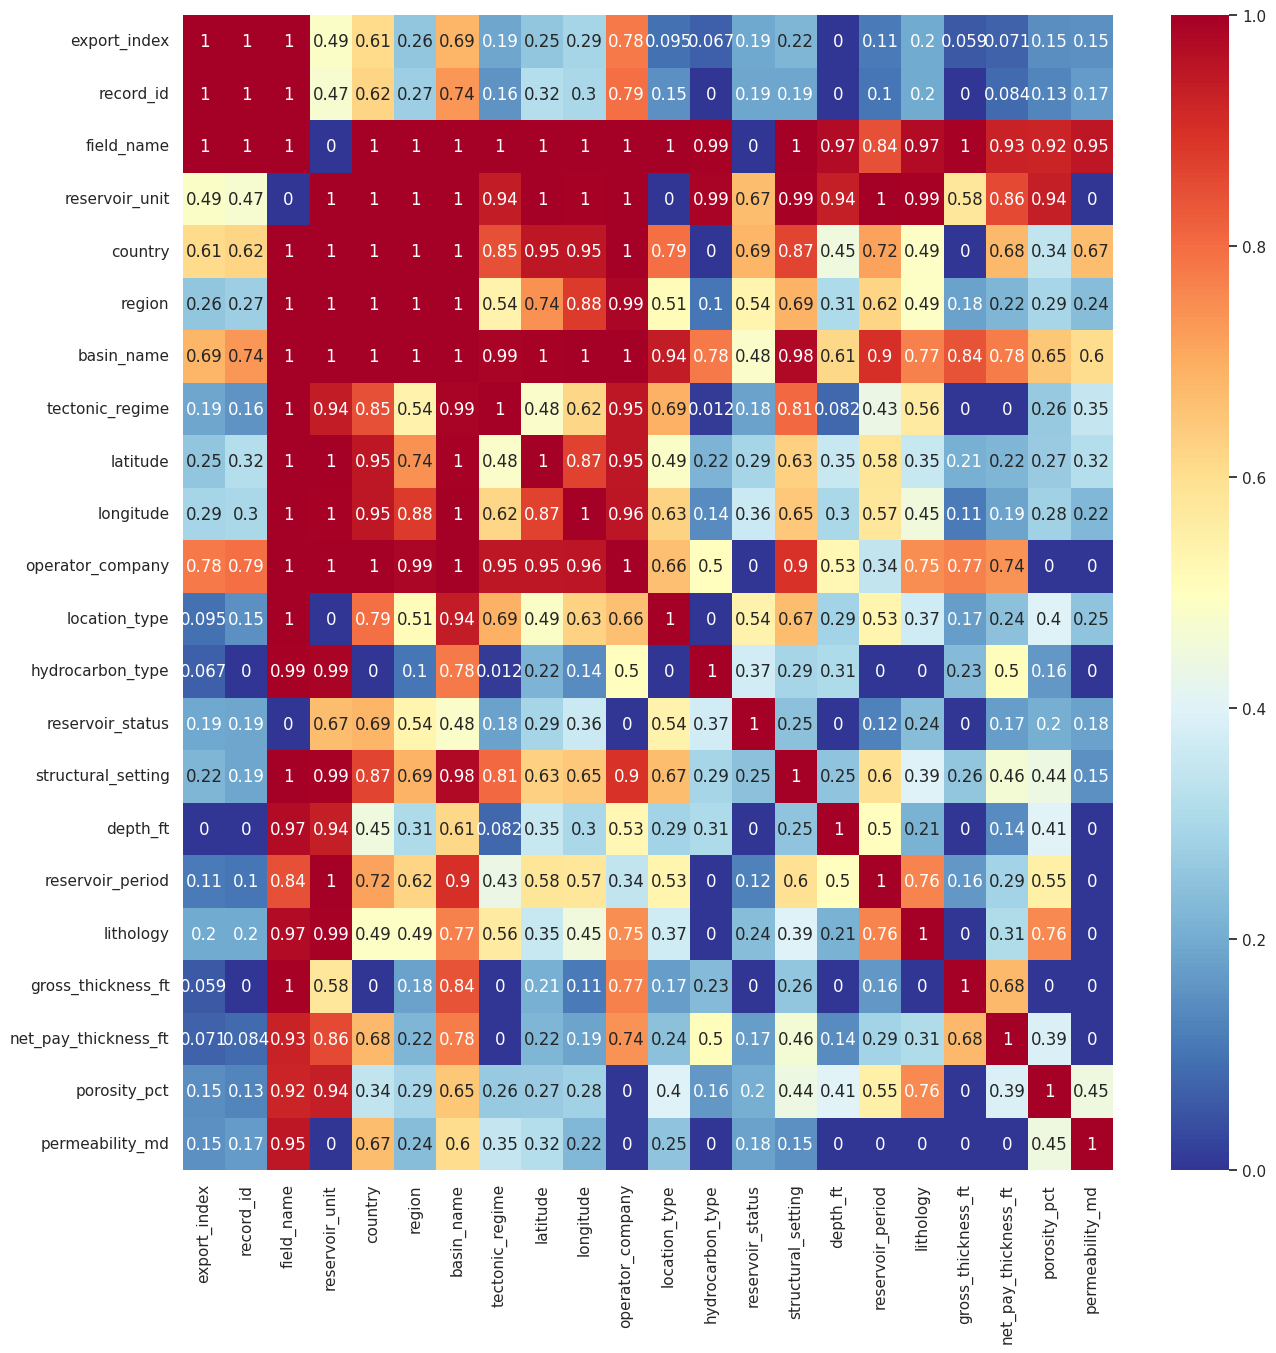

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(eda_data.phik_matrix(), cmap="RdYlBu_r", annot=True);

### Устойчивость выводов

#### Что зависит от одной точки или хвоста?

После исследования подозрительных записей полезно пересчитать выбранные описательные показатели на нескольких явно заданных сценариях.

Для связи пористости и проницаемости сравним все 442 пары, пары без значения пористости 55%, пары без верхнего 1% проницаемости.

In [ ]:
permeability_99_threshold = porosity_permeability_data['permeability_md'].quantile(0.99)
sensitivity_scenarios = {'Все известные пары': porosity_permeability_data, 'Без пористости > 50%': porosity_permeability_data.loc[porosity_permeability_data['porosity_pct'].le(50)], 'Без верхнего 1% проницаемости': porosity_permeability_data.loc[porosity_permeability_data['permeability_md'].le(permeability_99_threshold)]}
sensitivity_rows = []
for scenario_name in sensitivity_scenarios:
    scenario_data = sensitivity_scenarios[scenario_name]
    sensitivity_rows.append({'scenario': scenario_name, 'paired_count': len(scenario_data), 'excluded_from_complete_pairs': len(porosity_permeability_data) - len(scenario_data), 'pearson': scenario_data['porosity_pct'].corr(scenario_data['permeability_md']), 'spearman': scenario_data['porosity_pct'].corr(scenario_data['permeability_md'], method='spearman')})
sensitivity_summary = pd.DataFrame(sensitivity_rows)
sensitivity_summary

,scenario,paired_count,excluded_from_complete_pairs,pearson,spearman
0,Все известные пары,442,0,0.473850,0.657703
1,Без пористости > 50%,441,1,0.492775,0.667035
2,Без верхнего 1% проницаемости,437,5,0.510934,0.650792


Положительное направление в этих сценариях сохраняется, но величина меняется.

### Что мы не выяснили

- Как файл собран и как отбирались объекты, поэтому не заявляем репрезентативность.
- Каковы источники, точность и методики усреднения измерений
- Какие сведения доступны в конкретный момент использования
- Будут ли наблюдаемые связи сохраняться на новых объектах

### Чек-лист аналитика

Перед любым графиком:
- Какой конкретный вопрос задаём и какая единица наблюдения отвечает на него?
- Какие строки участвуют, сколько их и почему остальные исключены?
- Что означает каждая ось: значения, число строк, доля или плотность?
- Каковы единицы, интервалы, нормировка и знаменатель?

Перед выводом:
- Подтверждает ли график утверждение, или мы добавляем к нему неподтверждённую гипотезу?
- Может ли эффект быть результатом состава групп, округления, повторных объектов или пропусков?
- Сохраняется ли наблюдение при разумном изменении масштаба и интервалов?
- Нужно ли проверить необычный объект отдельно?
- Относится ли вывод к данной выборке, к известным измерениям или к более широкой совокупности?
